In [20]:
import glob
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta

def formatted_datetime():
    input_file = os.path.basename("/Users/Indhuja/Desktop/sc-radiosonde/SCRX_Radiosonde_CPEXAW_win_20210826_2140.txt")

    date_str, time_str = input_file.split("_")[-2:]
    # print(date_str)
    time_str = time_str.replace(".txt", "")
    # print(time_str)

    datetime_str = f"{date_str}_{time_str}"
    # print(datetime_str)
    # Parsing the datetime string
    original_datetime = datetime.strptime(datetime_str, "%Y%m%d_%H%M")
    # print(original_datetime)

    return original_datetime.strftime("%Y-%m-%dT%H:%M:%S")

def data_reader():

    date = "20210826"
    time = "214000"
    file = glob.glob("/Users/Indhuja/Desktop/sc-radiosonde/SCRX_Radiosonde_CPEXAW_win_20210826_2140.txt")

    df = pd.read_table(file[0],encoding = "ISO-8859-1")
    pd.set_option('display.max_colwidth', 10)
    print("hello")
    print(df.columns.values)

    column_name_changes = {
        'Time [sec]': 'Time',
        'P [h Pa]': 'Pres',
        'T [°C]': 'Temp',
        'U [%]': 'RH',
        'Wsp [m/s]' : 'Wsp', 
        'Wdir [°]' : 'Wdir',
        'Lon [°]   ': 'Lon',
        'Lat [°]  ': 'Lat',
        'Altitude [m]': 'Alt',
        'Dew [°C]': 'DP'
    }


    df.rename(columns=column_name_changes, inplace=True)
    valid_columns = list(column_name_changes.values())
    print(valid_columns)
    df = df[valid_columns]
    # df.replace('-----', pd.NA, inplace=True)
    # df.replace('-----    ', pd.NA, inplace=True)
    # df.replace('-----   ', pd.NA, inplace=True)

    #remove null(dashed) values and unwanted spaces in rows
    df.replace(r'^-{5,}\s*$', pd.NA, regex=True, inplace=True)
    df = df.map(lambda x: x.strip() if isinstance(x, str) else x) 
    df.dropna(inplace=True)

    start_time = pd.to_datetime(formatted_datetime())
    df['Datetime'] = start_time + pd.to_timedelta(df['Time'], unit='s')
    df['RH'] = pd.to_numeric(df['RH'], errors='coerce') 
    # with np.printoptions(threshold=np.inf):
    #     print(df['Wsp'])
    # df['Pres'] = pd.to_numeric(df['Pres'], errors='coerce') 
    # print(df)

    # wsp = pd.to_numeric(df['Wsp'], errors='coerce')
    # unique, counts = np.unique(wsp, return_counts=True)

    # selected_speeds = []
    # for speed, count in zip(unique, counts):
    #     if speed > 10 and count > 20:
    #         selected_speeds.append(speed)

    # print(selected_speeds)
    
    # df = df[df['Wsp'].astype(float).isin(selected_speeds)].reset_index(drop=True)
    # print(df)

    df = df.sort_values(by='Time').reset_index(drop=True)

    sort_idx = np.argsort(df['Time'])

    lon = df['Lon'][sort_idx]
    lat = df['Lat'][sort_idx]
    alt = df['Alt'][sort_idx]
    time = df['Time'][sort_idx]
    rh = df['RH'][sort_idx]
    dp = df['DP'][sort_idx]
    tdry = df['Temp'][sort_idx]
    pressure = df['Pres'][sort_idx]
    wsp = df['Wsp'][sort_idx]
    wdir = df['Wdir'][sort_idx]


    mask = np.logical_and(alt != -999.0, lon != -999.0, lat != -999.0)
    lon = lon[mask]
    lat = lat[mask]
    alt = alt[mask]
    time = time[mask]
    rh = rh[mask]
    dp = dp[mask]
    tdry = tdry[mask]
    pressure = pressure[mask]
    wsp = wsp[mask]
    wdir = wdir[mask]

    mask = np.logical_and(rh > -100, rh > -100)
    lon = lon[mask]
    lat = lat[mask]
    alt = alt[mask]
    time = time[mask]
    rh = rh[mask]
    dp = dp[mask]
    tdry = tdry[mask]
    pressure = pressure[mask]
    wsp = wsp[mask]
    wdir = wdir[mask]

    # print(dict(zip(unique, counts)))
    # threshold = 10
    # sampled_wind_speeds = unique[counts >= threshold]
    # sampled_occurrences = counts[counts >= threshold]
    # print(sampled_wind_speeds)

    lon = lon[mask]
    lat = lat[mask]
    alt = alt[mask]
    time = time[mask]
    rh = rh[mask]
    dp = dp[mask]
    tdry = tdry[mask]
    pressure = pressure[mask]
    wsp = wsp[mask]
    wdir = wdir[mask]

    return (lon, lat, alt, time, rh, dp, tdry, pressure, wsp, wdir)

data_reader()

hello
['Time [sec]' 'P [h Pa]' 'T [°C]' 'U [%]' 'Wsp [m/s]' 'Wdir [°]'
 'Lon [°]   ' 'Lat [°]  ' 'Altitude [m]' "Geo Pot [m']" 'MRI   ' 'RI   '
 'Dew [°C]' 'Vi Te [°C]' 'Rs [m/s]' 'D [kg/m3]' 'Azimuth [°]'
 'Elevation [°]' 'Range [m]']
['Time', 'Pres', 'Temp', 'RH', 'Wsp', 'Wdir', 'Lon', 'Lat', 'Alt', 'DP']


(0      -64.831763
 1      -64.831789
 2      -64.831815
 3      -64.831840
 4      -64.831866
           ...    
 2417   -64.984090
 2418   -64.984170
 2419   -64.984250
 2420   -64.984329
 2421   -64.984409
 Name: Lon, Length: 2422, dtype: float64,
 0       17.762488
 1       17.762471
 2       17.762454
 3       17.762438
 4       17.762421
           ...    
 2417    17.645602
 2418    17.645604
 2419    17.645605
 2420    17.645606
 2421    17.645607
 Name: Lat, Length: 2422, dtype: float64,
 0           0.0
 1           5.5
 2          11.1
 3          16.6
 4          22.2
          ...   
 2417    16793.0
 2418    16798.5
 2419    16804.1
 2420    16809.7
 2421    16815.3
 Name: Alt, Length: 2422, dtype: float64,
 0          0
 1          1
 2          2
 3          3
 4          4
         ... 
 2417    3136
 2418    3137
 2419    3138
 2420    3139
 2421    3140
 Name: Time, Length: 2422, dtype: int64,
 0       60
 1       62
 2       63
 3       65
 4       66
         ..
 2

# USING LIBRARIES TO PLOT SKEW-T DIAGRAM

In [21]:
data = data_reader()
(lon, lat, alt, time, rh, dp, tdry, pressure, wsp, wdir) = data

hello
['Time [sec]' 'P [h Pa]' 'T [°C]' 'U [%]' 'Wsp [m/s]' 'Wdir [°]'
 'Lon [°]   ' 'Lat [°]  ' 'Altitude [m]' "Geo Pot [m']" 'MRI   ' 'RI   '
 'Dew [°C]' 'Vi Te [°C]' 'Rs [m/s]' 'D [kg/m3]' 'Azimuth [°]'
 'Elevation [°]' 'Range [m]']
['Time', 'Pres', 'Temp', 'RH', 'Wsp', 'Wdir', 'Lon', 'Lat', 'Alt', 'DP']


In [22]:
# unique, counts = np.unique(wsp, return_counts=True)
# # wind_speed = dict(zip(unique, counts))
# # wind_speed_values, occurrences = zip(*wind_speed.items())
# threshold = 10
# sampled_wind_speeds = unique[counts >= threshold]
# sampled_occurrences = counts[counts >= threshold]
# wsp = list(zip(sampled_wind_speeds, sampled_occurrences))
print(wsp)

0       0.5
1       0.4
2       0.3
3       0.2
4       0.2
       ... 
2417    8.1
2418    8.2
2419    8.3
2420    8.4
2421    8.5
Name: Wsp, Length: 2422, dtype: object


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units
from metpy.calc import wind_components
import pint

In [24]:
# Change default to be better for skew-T
plt.rcParams['figure.figsize'] = (9, 9)

In [25]:
print(wsp)
df = pd.DataFrame(dict(zip(('height','pressure','temperature','dewpoint','wsp','wdir'),(alt,pressure,tdry,dp,wsp,wdir))))
print(df)
# Drop any rows with all NaN values for T, Td, winds
df = df.dropna(subset=('height','pressure','temperature','dewpoint','wsp','wdir', 
                       ), how='all').reset_index(drop=True)

print(df)


0       0.5
1       0.4
2       0.3
3       0.2
4       0.2
       ... 
2417    8.1
2418    8.2
2419    8.3
2420    8.4
2421    8.5
Name: Wsp, Length: 2422, dtype: object
       height  pressure  temperature  dewpoint  wsp wdir
0         0.0    1010.0      30.00        21.4  0.5  060
1         5.5    1009.4      29.82        21.6  0.4  067
2        11.1    1008.8      29.65        21.9  0.3  079
3        16.6    1008.1      29.47        22.1  0.2  099
4        22.2    1007.5      29.30        22.4  0.2  129
...       ...       ...        ...         ...  ...  ...
2417  16793.0      98.4     -72.21       -81.9  8.1  088
2418  16798.5      98.3     -72.25       -81.9  8.2  088
2419  16804.1      98.2     -72.29       -82.0  8.3  088
2420  16809.7      98.1     -72.33       -82.0  8.4  089
2421  16815.3      98.1     -72.37       -82.0  8.5  089

[2422 rows x 6 columns]
       height  pressure  temperature  dewpoint  wsp wdir
0         0.0    1010.0      30.00        21.4  0.5  060
1     

In [26]:
print(df['pressure'].dtype)
df['pressure'] = pd.to_numeric(df['pressure'], errors='coerce')
print(df['pressure'].dtype)
P = df['pressure'].values.astype(float) * units.hPa
T = df['temperature'].values * units.degC
df['dewpoint'] = pd.to_numeric(df['dewpoint'], errors='coerce')
print(df['dewpoint'].dtype)
Td = df['dewpoint'].values * units.degC
print((df['dewpoint']))

# ureg = pint.UnitRegistry()

wsp = df['wsp'].values.astype(float) * units('m/s')
# wsp = wsp * ureg('m/s')
print(wsp)

df['wdir'] = pd.to_numeric(df['wdir'], errors='coerce')
wdir = np.array(df['wdir'].values)


wdir_rad = np.radians(wdir)
# u_wind = wsp * np.sin(wdir_rad)
# v_wind = wsp * np.cos(wdir_rad)
u_wind, v_wind = wind_components(wsp , wdir_rad)

float64
float64
float64
0       21.4
1       21.6
2       21.9
3       22.1
4       22.4
        ... 
2417   -81.9
2418   -81.9
2419   -82.0
2420   -82.0
2421   -82.0
Name: dewpoint, Length: 2422, dtype: float64
[0.5 0.4 0.3 ... 8.3 8.4 8.5] meter / second


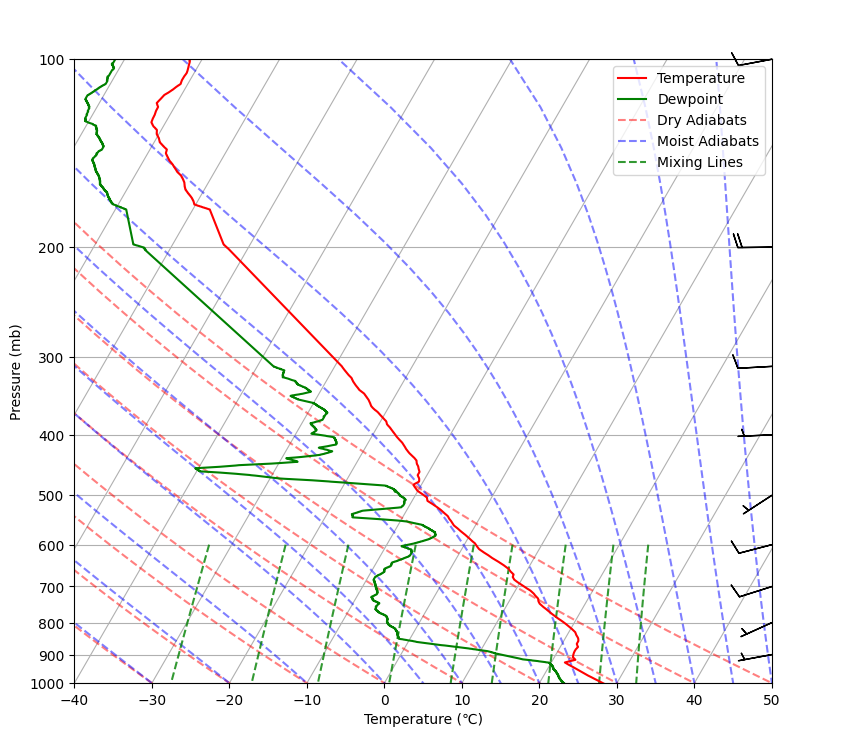

In [29]:
skew = SkewT()

# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot
skew.plot(P, T, 'r', label='Temperature')
skew.plot(P, Td, 'g', label='Dewpoint')

# # Set some better labels than the default
skew.ax.set_xlabel('Temperature (\N{DEGREE CELSIUS})')
skew.ax.set_ylabel('Pressure (mb)')

## for barbs

# Set spacing interval--Every 50 mb from 1000 to 100 mb
my_interval = np.arange(100, 1000, 100) * units('mbar')

# Get indexes of values closest to defined interval
ix = mpcalc.resample_nn_1d(P, my_interval)
skew.plot_barbs(P[ix], wsp[ix], wdir_rad[ix])

# Add the relevant special lines
skew.plot_dry_adiabats(label='Dry Adiabats')
skew.plot_moist_adiabats(label='Moist Adiabats')
skew.plot_mixing_lines(label='Mixing Ratio')
skew.ax.set_ylim(1000, 100)

plt.legend()
plt.show()

In [28]:
t = data['Datetime'].values
print(len(t))
# with np.printoptions(threshold=np.inf):
#     print(t)

sort_idx = np.argsort(t)
with np.printoptions(threshold=np.inf):
    print(sort_idx)

TypeError: tuple indices must be integers or slices, not str